In [1]:
# ============================================================
# PHASE 4 — Hard Vote
# Cellule 1 : Chargement données + modèles
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, joblib, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

tf.random.set_seed(42)
np.random.seed(42)

# ── Chemins ───────────────────────────────────────────────
BASE_DIR      = r"C:\PFA_Malware"
processed_dir = os.path.join(BASE_DIR, "data", "processed")
models_dir    = os.path.join(BASE_DIR, "models")
results_dir   = os.path.join(BASE_DIR, "results")

# ── Charger données test ───────────────────────────────────
X_m_test  = np.load(os.path.join(processed_dir, "malmem_X_test.npy"))
y_m_test  = np.load(os.path.join(processed_dir, "malmem_y_test.npy"))
X_e_test  = np.load(os.path.join(processed_dir, "ember_X_test.npy"))
y_e_test  = np.load(os.path.join(processed_dir, "ember_y_test.npy"))

# Reshape pour CNN1D
X_m_test_dl = X_m_test.reshape(-1, X_m_test.shape[1], 1)
X_e_test_dl = X_e_test.reshape(-1, X_e_test.shape[1], 1)

# ── Charger modèles ML ────────────────────────────────────
rf_malmem  = joblib.load(os.path.join(models_dir, "rf_malmem.pkl"))
rf_ember   = joblib.load(os.path.join(models_dir, "rf_ember.pkl"))
xgb_malmem = joblib.load(os.path.join(models_dir, "xgb_malmem.pkl"))
xgb_ember  = joblib.load(os.path.join(models_dir, "xgb_ember.pkl"))
lgb_malmem = joblib.load(os.path.join(models_dir, "lgb_malmem.pkl"))
lgb_ember  = joblib.load(os.path.join(models_dir, "lgb_ember.pkl"))
print("✅ Modèles ML chargés")

# ── Charger modèles DL ────────────────────────────────────
from tensorflow.keras.utils import custom_object_scope

# Définir les classes custom pour FT-Transformer
class FeatureTokenizer(keras.layers.Layer):
    def __init__(self, n_features, d_token, **kwargs):
        super().__init__(**kwargs)
        self.n_features = n_features
        self.d_token    = d_token
    def build(self, input_shape):
        self.W = self.add_weight(shape=(self.n_features, self.d_token),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(self.n_features, self.d_token),
                                  initializer='zeros', trainable=True)
        super().build(input_shape)
    def call(self, x):
        return x[:, :, None] * self.W[None, :, :] + self.b[None, :, :]
    def get_config(self):
        config = super().get_config()
        config.update({'n_features': self.n_features, 'd_token': self.d_token})
        return config

class ClsToken(keras.layers.Layer):
    def __init__(self, d_token, **kwargs):
        super().__init__(**kwargs)
        self.d_token = d_token
    def build(self, input_shape):
        self.cls = self.add_weight(shape=(1, 1, self.d_token),
                                    initializer='zeros', trainable=True)
        super().build(input_shape)
    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.repeat(self.cls, batch_size, axis=0)
        return tf.concat([cls_tokens, x], axis=1)
    def get_config(self):
        config = super().get_config()
        config.update({'d_token': self.d_token})
        return config

class TransformerBlock(keras.layers.Layer):
    def __init__(self, d_token, n_heads, ffn_factor=2.0,
                 dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_token      = d_token
        self.n_heads      = n_heads
        self.ffn_factor   = ffn_factor
        self.dropout_rate = dropout_rate
    def build(self, input_shape):
        self.attention = keras.layers.MultiHeadAttention(
            num_heads=self.n_heads,
            key_dim=self.d_token // self.n_heads,
            dropout=self.dropout_rate)
        self.ffn = keras.Sequential([
            keras.layers.Dense(int(self.d_token * self.ffn_factor),
                               activation='relu'),
            keras.layers.Dropout(self.dropout_rate),
            keras.layers.Dense(self.d_token)])
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1  = keras.layers.Dropout(self.dropout_rate)
        self.drop2  = keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)
    def call(self, x, training=False):
        attn_out = self.attention(self.norm1(x), self.norm1(x),
                                   training=training)
        attn_out = self.drop1(attn_out, training=training)
        x = x + attn_out
        ffn_out = self.ffn(self.norm2(x), training=training)
        ffn_out = self.drop2(ffn_out, training=training)
        return x + ffn_out
    def get_config(self):
        config = super().get_config()
        config.update({'d_token': self.d_token, 'n_heads': self.n_heads,
                       'ffn_factor': self.ffn_factor,
                       'dropout_rate': self.dropout_rate})
        return config

custom_objects = {
    'FeatureTokenizer': FeatureTokenizer,
    'ClsToken'        : ClsToken,
    'TransformerBlock': TransformerBlock
}

cnn_malmem = keras.models.load_model(
    os.path.join(models_dir, "cnn1d_malmem.keras"))
cnn_ember  = keras.models.load_model(
    os.path.join(models_dir, "cnn1d_ember.keras"))
ft_malmem  = keras.models.load_model(
    os.path.join(models_dir, "ft_transformer_malmem.keras"),
    custom_objects=custom_objects)
ft_ember   = keras.models.load_model(
    os.path.join(models_dir, "ft_transformer_ember.keras"),
    custom_objects=custom_objects)
print("✅ Modèles DL chargés")

# ── Seuils optimaux Phase 3 ───────────────────────────────
THRESHOLD_CNN_M = 0.397
THRESHOLD_CNN_E = 0.478
THRESHOLD_FT_M  = 0.100
THRESHOLD_FT_E  = 0.414

print("\n=== Données et modèles prêts ===")
print(f"CIC-MalMem test : {X_m_test.shape}")
print(f"EMBER test      : {X_e_test.shape}")
print("✅ Phase 4 prête à démarrer !")

✅ Modèles ML chargés

✅ Modèles DL chargés

=== Données et modèles prêts ===
CIC-MalMem test : (8705, 28)
EMBER test      : (200000, 200)
✅ Phase 4 prête à démarrer !


In [2]:
# ============================================================
# Cellule 2 : Fusion — Hard Vote + Soft Vote + Weighted Vote
# Version corrigée — poids basés sur val set
# ============================================================

# ── Seuils optimaux — tous issus du val set Phase 3 ────────
THRESHOLDS = {
    'RF_malmem'  : 0.5,   'RF_ember'  : 0.5,
    'XGB_malmem' : 0.5,   'XGB_ember' : 0.5,
    'LGB_malmem' : 0.5,   'LGB_ember' : 0.5,
    'CNN_malmem' : 0.397, 'CNN_ember' : 0.478,
    'FT_malmem'  : 0.100, 'FT_ember'  : 0.414,
}

# ── Charger val sets pour calcul des poids ─────────────────
X_m_val    = np.load(os.path.join(processed_dir,
                     "malmem_X_val.npy"))
y_m_val    = np.load(os.path.join(processed_dir,
                     "malmem_y_val.npy"))
X_e_val    = np.load(os.path.join(processed_dir,
                     "ember_X_val.npy"))
y_e_val    = np.load(os.path.join(processed_dir,
                     "ember_y_val.npy"))
X_m_val_dl = X_m_val.reshape(-1, X_m_val.shape[1], 1)
X_e_val_dl = X_e_val.reshape(-1, X_e_val.shape[1], 1)

def get_probas_and_votes(model, X, threshold,
                          use_predict_proba=True):
    """Retourne probabilités et votes binaires."""
    if use_predict_proba:
        probas = model.predict_proba(X)[:, 1]
    else:
        probas = model.predict(X, verbose=0).flatten()
    votes = (probas >= threshold).astype(int)
    return probas, votes

def compute_val_f1(model, X_val, y_val, threshold,
                    use_predict_proba=True):
    """
    Calcule le F1 sur le VAL SET uniquement.
    Ces F1 servent exclusivement à construire les poids
    du Weighted Vote — jamais le test set.
    """
    if use_predict_proba:
        probas = model.predict_proba(X_val)[:, 1]
    else:
        probas = model.predict(X_val, verbose=0).flatten()
    y_pred = (probas >= threshold).astype(int)
    return f1_score(y_val, y_pred, zero_division=0)

# ── Calcul des poids depuis le VAL SET ─────────────────────
print("Calcul des poids depuis le val set...")

# CIC-MalMem — val F1 par modèle
w_rf_m  = compute_val_f1(rf_malmem,  X_m_val,
                          y_m_val, THRESHOLDS['RF_malmem'])
w_xgb_m = compute_val_f1(xgb_malmem, X_m_val,
                          y_m_val, THRESHOLDS['XGB_malmem'])
w_lgb_m = compute_val_f1(lgb_malmem, X_m_val,
                          y_m_val, THRESHOLDS['LGB_malmem'])
w_cnn_m = compute_val_f1(cnn_malmem, X_m_val_dl,
                          y_m_val, THRESHOLDS['CNN_malmem'],
                          use_predict_proba=False)
w_ft_m  = compute_val_f1(ft_malmem,  X_m_val,
                          y_m_val, THRESHOLDS['FT_malmem'],
                          use_predict_proba=False)

WEIGHTS_MALMEM = {
    'RF': w_rf_m, 'XGBoost': w_xgb_m,
    'LGB': w_lgb_m, 'CNN1D': w_cnn_m,
    'FT': w_ft_m
}

print("\nPoids CIC-MalMem (val set F1) :")
for k, v in WEIGHTS_MALMEM.items():
    print(f"  {k:<12} : {v:.4f}")

# EMBER — val F1 par modèle
w_rf_e  = compute_val_f1(rf_ember,  X_e_val,
                          y_e_val, THRESHOLDS['RF_ember'])
w_xgb_e = compute_val_f1(xgb_ember, X_e_val,
                          y_e_val, THRESHOLDS['XGB_ember'])
w_lgb_e = compute_val_f1(lgb_ember, X_e_val,
                          y_e_val, THRESHOLDS['LGB_ember'])
w_cnn_e = compute_val_f1(cnn_ember, X_e_val_dl,
                          y_e_val, THRESHOLDS['CNN_ember'],
                          use_predict_proba=False)
w_ft_e  = compute_val_f1(ft_ember,  X_e_val,
                          y_e_val, THRESHOLDS['FT_ember'],
                          use_predict_proba=False)

WEIGHTS_EMBER = {
    'RF': w_rf_e, 'XGBoost': w_xgb_e,
    'LGB': w_lgb_e, 'CNN1D': w_cnn_e,
    'FT': w_ft_e
}

print("\nPoids EMBER (val set F1) :")
for k, v in WEIGHTS_EMBER.items():
    print(f"  {k:<12} : {v:.4f}")

def compute_all_strategies(probas_dict, votes_dict,
                            weights_dict, y_true,
                            dataset_name):
    """
    3 stratégies de fusion :

    Hard Vote     : vote binaire ≥3/5 — logique de majorité pure
                    confidence = fraction des votes malware (0-1)
                    → mesure de confiance du vote lui-même

    Soft Vote     : moyenne des probabilités ≥ 0.5
                    confidence = moyenne des probabilités
                    → exploite l'information continue

    Weighted Vote : moyenne pondérée par F1 val set ≥ 0.5
                    poids calculés sur val set (pas test)
                    → donne plus de poids aux meilleurs modèles

    Note : Hard Vote confidence ≠ Soft Vote confidence
    Hard Vote confidence = votes_sum / n_models (fraction votes)
    Soft Vote confidence = mean(probabilities)
    """
    names   = list(probas_dict.keys())
    probas  = list(probas_dict.values())
    votes   = list(votes_dict.values())
    weights = np.array([weights_dict[n] for n in names])

    results = {}

    # ── 1. Hard Vote ────────────────────────────────────────
    votes_sum = np.sum(votes, axis=0)
    y_hard    = (votes_sum >= 3).astype(int)
    # Confidence Hard Vote = fraction des votes malware
    # C'est une mesure de confiance du vote lui-même
    # distincte de la moyenne des probabilités
    conf_hard = votes_sum / len(names)
    results['Hard Vote'] = {
        'y_pred'    : y_hard,
        'confidence': conf_hard,
        'votes_sum' : votes_sum
    }

    # ── 2. Soft Vote ────────────────────────────────────────
    conf_soft = np.mean(probas, axis=0)
    y_soft    = (conf_soft >= 0.5).astype(int)
    results['Soft Vote'] = {
        'y_pred'    : y_soft,
        'confidence': conf_soft
    }

    # ── 3. Weighted Vote ────────────────────────────────────
    # Poids normalisés depuis val set F1 — pas le test set
    weights_norm  = weights / weights.sum()
    conf_weighted = np.average(probas,
                                weights=weights_norm,
                                axis=0)
    y_weighted    = (conf_weighted >= 0.5).astype(int)
    results['Weighted Vote'] = {
        'y_pred'    : y_weighted,
        'confidence': conf_weighted
    }

    # ── Évaluation des 3 stratégies ─────────────────────────
    print(f"\n{'='*60}")
    print(f"RÉSULTATS FUSION — {dataset_name}")
    print(f"{'='*60}")

    metrics_list = []
    for strategy, data in results.items():
        y_pred = data['y_pred']
        conf   = data['confidence']

        m = {
            'Stratégie': strategy,
            'Dataset'  : dataset_name,
            'Accuracy' : round(accuracy_score(
                              y_true, y_pred), 4),
            'Precision': round(precision_score(
                              y_true, y_pred,
                              zero_division=0), 4),
            'Recall'   : round(recall_score(
                              y_true, y_pred,
                              zero_division=0), 4),
            'F1'       : round(f1_score(
                              y_true, y_pred,
                              zero_division=0), 4),
            'AUC-ROC'  : round(roc_auc_score(
                              y_true, conf), 4)
        }
        metrics_list.append(m)
        print(f"\n── {strategy} ──")
        for k, v in m.items():
            if k not in ['Stratégie', 'Dataset']:
                print(f"  {k:<10} : {v}")

    # Distribution votes Hard Vote
    print(f"\n── Distribution votes Hard Vote ──")
    unique, counts = np.unique(votes_sum,
                                return_counts=True)
    for u, c in zip(unique, counts):
        label = "← Malware" if u >= 3 else "← Bénin"
        print(f"  {int(u)}/5 votes : {c:6d} {label}")

    return results, metrics_list

# ── Charger résultats individuels depuis CSV ───────────────
# Robuste — pas de valeurs codées en dur
print("\nChargement résultats individuels...")
df_ml = pd.read_csv(os.path.join(results_dir,
                    "ml_results_final.csv"))
df_dl = pd.read_csv(os.path.join(results_dir,
                    "dl_results_final.csv"))
df_individuel = pd.concat([df_ml, df_dl], ignore_index=True)
print(f"✅ {len(df_individuel)} résultats individuels chargés")

# ══════════════════════════════════════════════════════════
# CIC-MalMem
# ══════════════════════════════════════════════════════════
print("\nCalcul prédictions CIC-MalMem...")
p_rf_m,  v_rf_m  = get_probas_and_votes(
    rf_malmem,  X_m_test,    THRESHOLDS['RF_malmem'])
p_xgb_m, v_xgb_m = get_probas_and_votes(
    xgb_malmem, X_m_test,    THRESHOLDS['XGB_malmem'])
p_lgb_m, v_lgb_m = get_probas_and_votes(
    lgb_malmem, X_m_test,    THRESHOLDS['LGB_malmem'])
p_cnn_m, v_cnn_m = get_probas_and_votes(
    cnn_malmem, X_m_test_dl, THRESHOLDS['CNN_malmem'],
    use_predict_proba=False)
p_ft_m,  v_ft_m  = get_probas_and_votes(
    ft_malmem,  X_m_test,    THRESHOLDS['FT_malmem'],
    use_predict_proba=False)

probas_m = {'RF':p_rf_m,'XGBoost':p_xgb_m,
            'LGB':p_lgb_m,'CNN1D':p_cnn_m,'FT':p_ft_m}
votes_m  = {'RF':v_rf_m,'XGBoost':v_xgb_m,
            'LGB':v_lgb_m,'CNN1D':v_cnn_m,'FT':v_ft_m}

results_m, metrics_m = compute_all_strategies(
    probas_m, votes_m, WEIGHTS_MALMEM,
    y_m_test, "CIC-MalMem")

# ══════════════════════════════════════════════════════════
# EMBER
# ══════════════════════════════════════════════════════════
print("\nCalcul prédictions EMBER...")
p_rf_e,  v_rf_e  = get_probas_and_votes(
    rf_ember,  X_e_test,    THRESHOLDS['RF_ember'])
p_xgb_e, v_xgb_e = get_probas_and_votes(
    xgb_ember, X_e_test,    THRESHOLDS['XGB_ember'])
p_lgb_e, v_lgb_e = get_probas_and_votes(
    lgb_ember, X_e_test,    THRESHOLDS['LGB_ember'])
p_cnn_e, v_cnn_e = get_probas_and_votes(
    cnn_ember, X_e_test_dl, THRESHOLDS['CNN_ember'],
    use_predict_proba=False)
p_ft_e,  v_ft_e  = get_probas_and_votes(
    ft_ember,  X_e_test,    THRESHOLDS['FT_ember'],
    use_predict_proba=False)

probas_e = {'RF':p_rf_e,'XGBoost':p_xgb_e,
            'LGB':p_lgb_e,'CNN1D':p_cnn_e,'FT':p_ft_e}
votes_e  = {'RF':v_rf_e,'XGBoost':v_xgb_e,
            'LGB':v_lgb_e,'CNN1D':v_cnn_e,'FT':v_ft_e}

results_e, metrics_e = compute_all_strategies(
    probas_e, votes_e, WEIGHTS_EMBER,
    y_e_test, "EMBER")

# ══════════════════════════════════════════════════════════
# Tableau comparatif — chargé depuis CSV (pas codé en dur)
# ══════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("TABLEAU COMPARATIF — Individuel vs Fusion")
print(f"{'='*70}")

# Résultats individuels depuis CSV
rows_individuel = []
for _, row in df_individuel.iterrows():
    rows_individuel.append({
        'Dataset': row['Dataset'],
        'Modèle' : row['Model'],
        'F1'     : row['F1'],
        'AUC-ROC': row['AUC-ROC'],
        'Type'   : 'Individuel'
    })

# Résultats fusion
rows_fusion = []
for m in metrics_m + metrics_e:
    rows_fusion.append({
        'Dataset': m['Dataset'],
        'Modèle' : m['Stratégie'],
        'F1'     : m['F1'],
        'AUC-ROC': m['AUC-ROC'],
        'Type'   : '★ Fusion'
    })

df_compare = pd.DataFrame(rows_individuel + rows_fusion)

for ds in ['CIC-MalMem', 'EMBER']:
    print(f"\n── {ds} ──")
    subset = df_compare[df_compare['Dataset']==ds]\
             [['Modèle','F1','AUC-ROC','Type']]
    print(subset.to_string(index=False))

print("\n✅ Comparaison complète terminée !")

# Variables pour cellules suivantes
all_results_m    = results_m
all_results_e    = results_e
all_metrics_list = metrics_m + metrics_e
all_metrics_df   = df_compare

Calcul des poids depuis le val set...

Poids CIC-MalMem (val set F1) :
  RF           : 0.9999
  XGBoost      : 1.0000
  LGB          : 1.0000
  CNN1D        : 1.0000
  FT           : 1.0000

Poids EMBER (val set F1) :
  RF           : 0.9470
  XGBoost      : 1.0000
  LGB          : 0.9851
  CNN1D        : 0.9641
  FT           : 0.9481

Chargement résultats individuels...
✅ 10 résultats individuels chargés

Calcul prédictions CIC-MalMem...

RÉSULTATS FUSION — CIC-MalMem

── Hard Vote ──
  Accuracy   : 1.0
  Precision  : 1.0
  Recall     : 1.0
  F1         : 1.0
  AUC-ROC    : 1.0

── Soft Vote ──
  Accuracy   : 1.0
  Precision  : 1.0
  Recall     : 1.0
  F1         : 1.0
  AUC-ROC    : 1.0

── Weighted Vote ──
  Accuracy   : 1.0
  Precision  : 1.0
  Recall     : 1.0
  F1         : 1.0
  AUC-ROC    : 1.0

── Distribution votes Hard Vote ──
  0/5 votes :   4384 ← Bénin
  3/5 votes :      1 ← Malware
  4/5 votes :      1 ← Malware
  5/5 votes :   4319 ← Malware

Calcul prédictions EMBER.

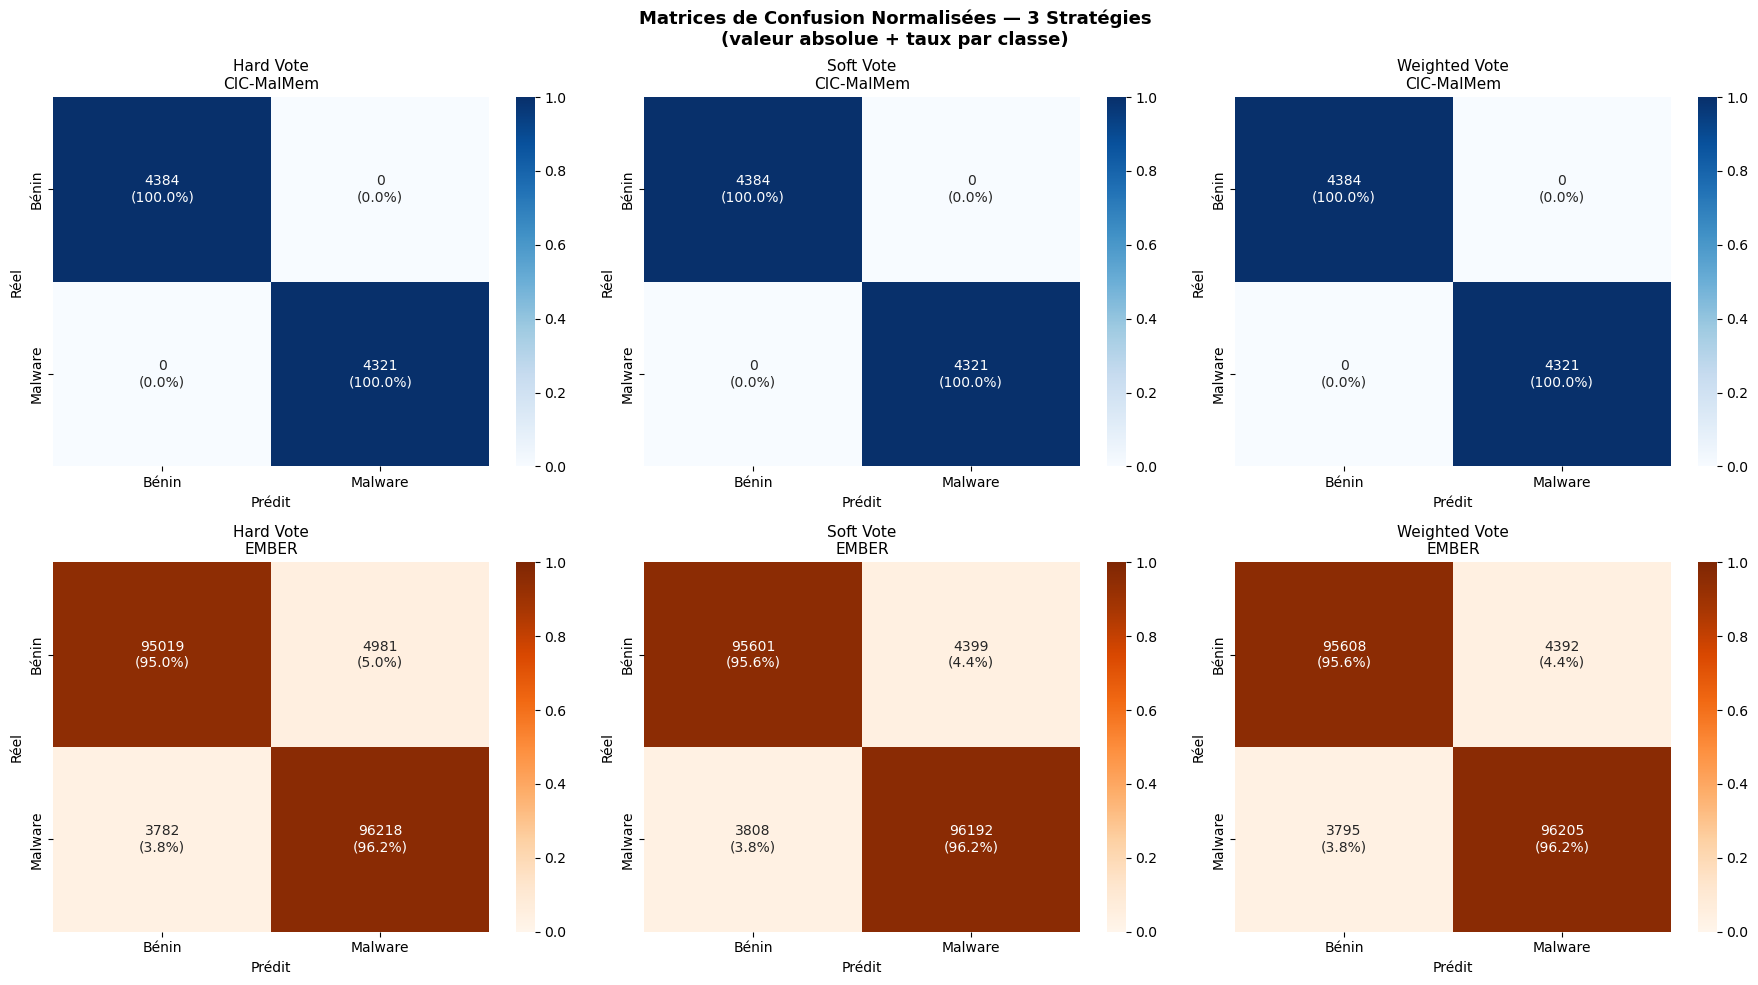

✅ Matrices de confusion normalisées sauvegardées


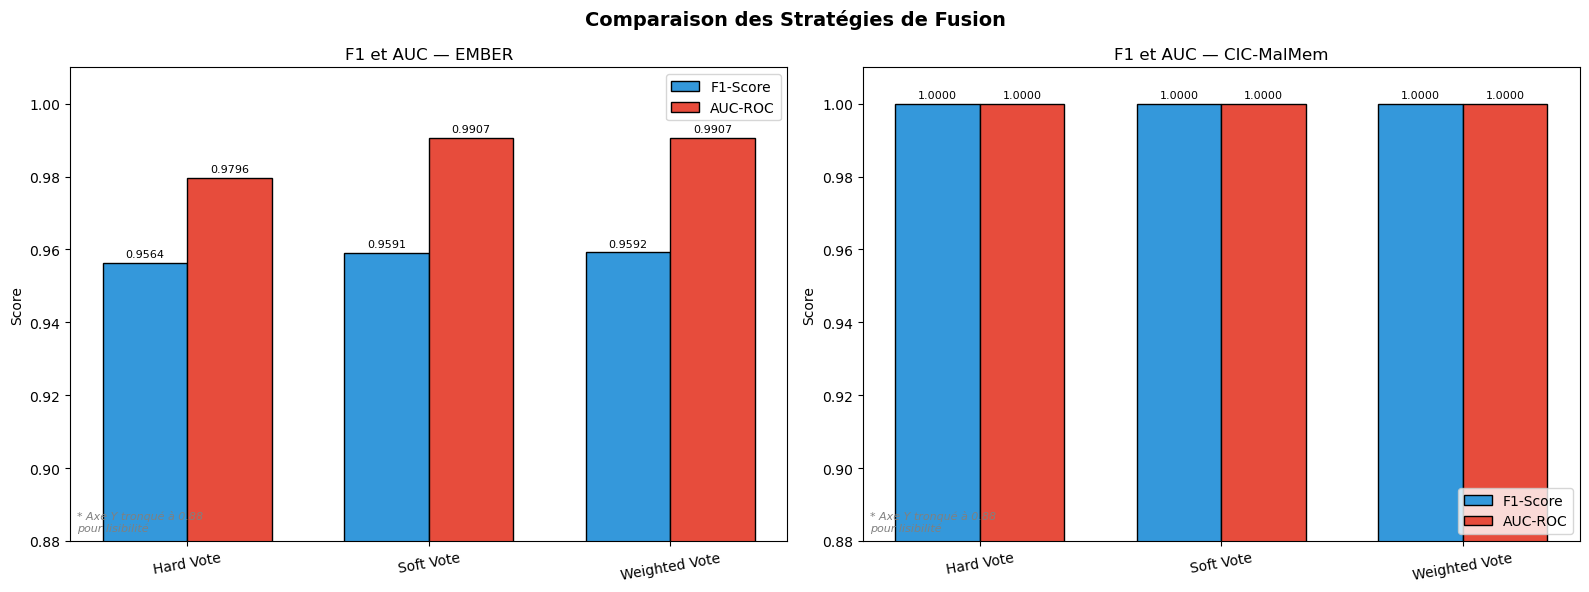

✅ Graphique comparaison sauvegardé


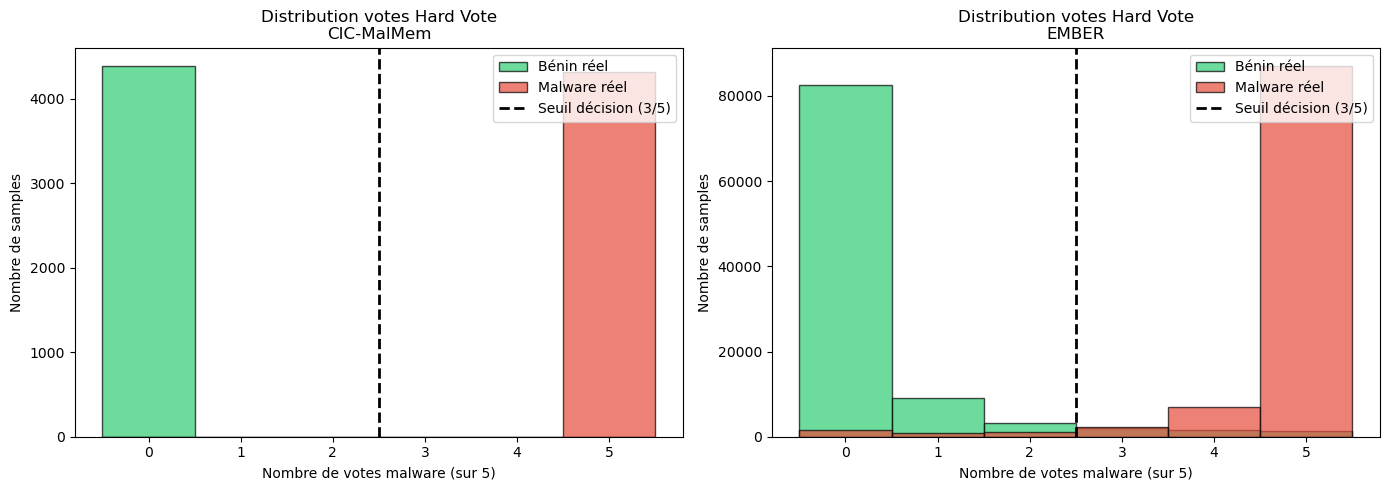

✅ Distribution des votes sauvegardée


In [3]:
# ============================================================
# Cellule 3 : Visualisations — 3 stratégies de fusion
# ============================================================

strategies = ['Hard Vote', 'Soft Vote', 'Weighted Vote']

# ── Matrices de confusion : absolues + normalisées ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, strategy in enumerate(strategies):
    for row, (y_true, results, title, cmap) in enumerate([
        (y_m_test, all_results_m, 'CIC-MalMem', 'Blues'),
        (y_e_test, all_results_e, 'EMBER',       'Oranges')
    ]):
        cm = confusion_matrix(y_true,
                              results[strategy]['y_pred'])
        # Normalisation par ligne (recall par classe)
        cm_norm = cm.astype(float) / cm.sum(axis=1,
                  keepdims=True)

        # Annotations : valeur absolue + pourcentage
        annot = np.array([
            [f"{v}\n({p:.1%})"
             for v, p in zip(row_v, row_p)]
            for row_v, row_p in zip(cm, cm_norm)
        ])

        sns.heatmap(cm_norm, annot=annot, fmt='',
                    cmap=cmap, ax=axes[row][col],
                    vmin=0, vmax=1,
                    xticklabels=['Bénin','Malware'],
                    yticklabels=['Bénin','Malware'])
        axes[row][col].set_title(
            f'{strategy}\n{title}', fontsize=11)
        axes[row][col].set_ylabel('Réel')
        axes[row][col].set_xlabel('Prédit')

plt.suptitle(
    'Matrices de Confusion Normalisées — 3 Stratégies\n'
    '(valeur absolue + taux par classe)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir,
            "fusion_confusion_matrices.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusion normalisées sauvegardées")

# ── Graphique F1 + AUC avec annotation axe tronqué ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, dataset, metrics_list in [
    (axes[0], 'EMBER',      metrics_e),
    (axes[1], 'CIC-MalMem', metrics_m)
]:
    strat_names = [m['Stratégie'] for m in metrics_list]
    f1_scores   = [m['F1']        for m in metrics_list]
    auc_scores  = [m['AUC-ROC']   for m in metrics_list]

    x     = np.arange(len(strat_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, f1_scores, width,
                   label='F1-Score', color='#3498db',
                   edgecolor='black')
    bars2 = ax.bar(x + width/2, auc_scores, width,
                   label='AUC-ROC', color='#e74c3c',
                   edgecolor='black')

    ax.set_ylim(0.88, 1.01)
    ax.set_xticks(x)
    ax.set_xticklabels(strat_names, rotation=10)
    ax.set_title(f'F1 et AUC — {dataset}', fontsize=12)
    ax.set_ylabel('Score')
    ax.legend()

    # Annotation axe tronqué — transparence méthodologique
    ax.annotate('* Axe Y tronqué à 0.88\npour lisibilité',
                xy=(0.01, 0.02),
                xycoords='axes fraction',
                fontsize=8, color='gray',
                style='italic')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparaison des Stratégies de Fusion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir,
            "fusion_strategies_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique comparaison sauvegardé")

# ── Distribution votes Hard Vote ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, votes_sum, y_true, title in [
    (axes[0], all_results_m['Hard Vote']['votes_sum'],
     y_m_test, 'CIC-MalMem'),
    (axes[1], all_results_e['Hard Vote']['votes_sum'],
     y_e_test, 'EMBER')
]:
    benin_votes   = votes_sum[y_true == 0]
    malware_votes = votes_sum[y_true == 1]

    ax.hist(benin_votes, bins=range(7), alpha=0.7,
            color='#2ecc71', label='Bénin réel',
            align='left', edgecolor='black')
    ax.hist(malware_votes, bins=range(7), alpha=0.7,
            color='#e74c3c', label='Malware réel',
            align='left', edgecolor='black')
    ax.axvline(x=2.5, color='black', linestyle='--',
               linewidth=2, label='Seuil décision (3/5)')
    ax.set_title(
        f'Distribution votes Hard Vote\n{title}',
        fontsize=12)
    ax.set_xlabel('Nombre de votes malware (sur 5)')
    ax.set_ylabel('Nombre de samples')
    ax.legend()
    ax.set_xticks(range(6))

plt.tight_layout()
plt.savefig(os.path.join(results_dir,
            "hardvote_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution des votes sauvegardée")

In [4]:
# ============================================================
# Cellule 4 : Sauvegarde finale Phase 4 — Version finale
# ============================================================

# ── Vérification variables critiques ───────────────────────
assert 'all_results_m' in dir(), \
    "❌ all_results_m manquant — relancer Cellule 2"
assert 'all_results_e' in dir(), \
    "❌ all_results_e manquant — relancer Cellule 2"
assert 'metrics_m' in dir(), \
    "❌ metrics_m manquant — relancer Cellule 2"
assert 'metrics_e' in dir(), \
    "❌ metrics_e manquant — relancer Cellule 2"
print("✅ Variables critiques vérifiées")

# ── Sécurisation des dossiers ───────────────────────────────
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir,  exist_ok=True)

# ── Tableau résultats fusion ────────────────────────────────
df_fusion = pd.DataFrame(all_metrics_list)
df_fusion.to_csv(os.path.join(results_dir,
                 "fusion_results.csv"), index=False)
print("✅ Résultats fusion sauvegardés")

# ── Tableau comparatif complet ──────────────────────────────
all_metrics_df.to_csv(os.path.join(results_dir,
                      "fusion_comparison_full.csv"),
                      index=False)
print("✅ Tableau comparatif sauvegardé")

# ── Labels vrais test set — pour réévaluation future ───────
np.save(os.path.join(results_dir, "y_test_malmem.npy"),
        y_m_test)
np.save(os.path.join(results_dir, "y_test_ember.npy"),
        y_e_test)
print("✅ Labels test set sauvegardés")

# ── Prédictions et confiances ──────────────────────────────
for strategy in ['Hard Vote', 'Soft Vote',
                  'Weighted Vote']:
    name = strategy.lower().replace(' ', '_')
    np.save(os.path.join(results_dir,
            f"{name}_pred_malmem.npy"),
            all_results_m[strategy]['y_pred'])
    np.save(os.path.join(results_dir,
            f"{name}_pred_ember.npy"),
            all_results_e[strategy]['y_pred'])
    np.save(os.path.join(results_dir,
            f"{name}_conf_malmem.npy"),
            all_results_m[strategy]['confidence'])
    np.save(os.path.join(results_dir,
            f"{name}_conf_ember.npy"),
            all_results_e[strategy]['confidence'])
print("✅ Prédictions et confiances sauvegardées")

# ── Poids Weighted Vote — conversion float explicite ───────
# Conversion numpy → float natif Python pour JSON
weights_config = {
    'CIC-MalMem': {
        k: float(v) for k, v in WEIGHTS_MALMEM.items()},
    'EMBER': {
        k: float(v) for k, v in WEIGHTS_EMBER.items()},
    'source': 'val set F1 scores — pas le test set'
}
with open(os.path.join(results_dir,
          "weighted_vote_weights.json"), "w") as f:
    json.dump(weights_config, f, indent=4)
print("✅ Poids Weighted Vote sauvegardés (float natif)")

# ── Résumé final ───────────────────────────────────────────
print(f"\n{'='*60}")
print("RÉSUMÉ FINAL — PHASE 4 TERMINÉE")
print(f"{'='*60}")

print("\n── CIC-MalMem ──")
for m in metrics_m:
    print(f"  {m['Stratégie']:<20} "
          f"F1={m['F1']:.4f}  AUC={m['AUC-ROC']:.4f}")

print("\n── EMBER ──")
for m in metrics_e:
    print(f"  {m['Stratégie']:<20} "
          f"F1={m['F1']:.4f}  AUC={m['AUC-ROC']:.4f}")

# ── Listing fichiers sauvegardés ───────────────────────────
print(f"\n{'='*60}")
print("Fichiers sauvegardés dans results/ :")
keywords = ['fusion', 'hard', 'soft',
            'weighted', 'y_test']
for f in sorted(os.listdir(results_dir)):
    if any(x in f for x in keywords):
        size = os.path.getsize(
            os.path.join(results_dir, f)) / 1024
        print(f"  {f:<45} {size:.1f} KB")

print("\n🎉 PHASE 4 — FUSION COMPLÈTEMENT TERMINÉE !")

✅ Variables critiques vérifiées
✅ Résultats fusion sauvegardés
✅ Tableau comparatif sauvegardé
✅ Labels test set sauvegardés
✅ Prédictions et confiances sauvegardées
✅ Poids Weighted Vote sauvegardés (float natif)

RÉSUMÉ FINAL — PHASE 4 TERMINÉE

── CIC-MalMem ──
  Hard Vote            F1=1.0000  AUC=1.0000
  Soft Vote            F1=1.0000  AUC=1.0000
  Weighted Vote        F1=1.0000  AUC=1.0000

── EMBER ──
  Hard Vote            F1=0.9564  AUC=0.9796
  Soft Vote            F1=0.9591  AUC=0.9907
  Weighted Vote        F1=0.9592  AUC=0.9907

Fichiers sauvegardés dans results/ :
  fusion_comparison_full.csv                    0.7 KB
  fusion_confusion_matrices.png                 145.2 KB
  fusion_results.csv                            0.3 KB
  fusion_strategies_comparison.png              80.8 KB
  hard_vote_conf_ember.npy                      1562.6 KB
  hard_vote_conf_malmem.npy                     68.1 KB
  hard_vote_pred_ember.npy                      1562.6 KB
  hard_vote_pred_ma